# Análise Exploratória — Rajada Máxima Diária por Predição Direta (IRC Vendaval)

Dataset: `artifacts/corrected_grid/v1.01/data.nc` — rajada de vento máxima
**diária** prevista em cada célula da bacia, 2000-2024.

**Este produto é gerado por um método diferente do anterior.** Antes
(`corrected_grid`): o modelo previa nas ESTAÇÕES e o resíduo era interpolado
(IDW) para a grade — a cobertura ficava amarrada à densidade de estações
naquele dia, e em 2000 (2 estações ativas) ~42% da bacia ficava vazia. Agora
(`grid_direct`): o modelo vencedor de cada cluster × trimestre é aplicado
DIRETAMENTE às features ERA5 de cada célula, então toda célula tem valor todo
dia, nos 25 anos.

**Estrutura** (diferente do produto anterior):
- dims `(time, cell)` = 9132 × 2129 — células empilhadas, não grade retangular
- variável única `rajada_max_prevista` (m/s); não há mais `bias` nem `direcao_vento`
- coords por célula: `latitude`, `longitude`, `cluster_id`
- **zero NaN** — o domínio são as 2129 células da bacia (união dos 14 clusters),
  que é exatamente a máscara já embutida no ERA5-Basin de origem

**Ressalvas medidas, não supostas** (ver seção 5):
- **Extremos subestimados**: p99 ~15,4 m/s contra ~20,6 do produto por IDW. Sem
  as features autoregressivas da observação (`lag1_gust_obs` etc.), o modelo
  perde o sinal de persistência de evento extremo. Para análise de evento
  severo, o produto por IDW ainda é mais sensível.
- 6 features do treino dependem de estação e são imputadas na grade:
  `lag1/2/3_gust_obs`, `rolling7d_gust_obs`, `gust_P50` (todos os pipelines) e
  `era5_clim_wind` (só lazy). Custo medido: ~14% de R² em mlp/lstm, ~45% em lazy.
- Treino agora cobre 2000-2018, então 19 dos 25 anos são in-sample.

## Índice

1. [Carregamento e visão geral](#1)
2. [Análise espacial](#2) — climatologia, sazonalidade, efeito da correção, clusters
3. [Análise temporal](#3) — série diária, tendência anual, ciclo sazonal, extremos, splits
4. [Séries em pontos específicos](#4)
5. [Modelos e qualidade](#5) — vencedores por cluster × trimestre, comparação com o produto IDW
6. [Exploração interativa por data](#6)
7. [Resumo](#7)


## 1. Carregamento e visão geral <a id="1"></a>


In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (10, 5)

DATA_FILE = Path("../artifacts/corrected_grid/v1.01/data.nc")
ERA5_FILE = Path("../dataset/raw/ERA5_Features_Basin_2000_2026.nc")
IDW_DIR = Path("../artifacts/corrected_grid/v102_2000_2024")  # produto anterior
VAR = "rajada_max_prevista"

# Splits atuais (src/pipelines/common.py) — TRAIN começa em 2000 desde 2026-09-01
TRAIN_SLICE = ("2000-01-01", "2018-12-31")
VAL_SLICE = ("2019-01-01", "2019-12-31")
TEST_SLICE = ("2020-01-01", "2024-12-31")


In [2]:
ds = xr.open_dataset(DATA_FILE)
gust = ds[VAR]
ds


<xarray.Dataset> Size: 78MB
Dimensions:              (time: 9132, cell: 2129)
Coordinates:
  * time                 (time) datetime64[ns] 73kB 2000-01-01 ... 2024-12-31
  * cell                 (cell) int64 17kB 0 1 2 3 4 ... 2125 2126 2127 2128
    latitude             (cell) float64 17kB ...
    longitude            (cell) float64 17kB ...
    cluster_id           (cell) int16 4kB ...
Data variables:
    rajada_max_prevista  (time, cell) float32 78MB ...
Attributes:
    source:              IRC Vendaval — predição direta por célula (sem IDW)
    metodo:              modelo vencedor por cluster × trimestre aplicado às ...
    dominio:             2129 células = união dos 14 clusters = máscara da bacia
    features_imputadas:  lag1/2/3_gust_obs, rolling7d_gust_obs, gust_P50 (tod...
    winners_csv:         /tmp/claude-1000/-media-matteuscruz-Projects-Entrep-...

In [3]:
print(f"Variável: {VAR}  ({gust.attrs.get('units', '?')})")
print(f"Período: {pd.Timestamp(ds.time.min().values).date()} .. "
      f"{pd.Timestamp(ds.time.max().values).date()}  ({ds.sizes['time']} dias)")
print(f"Células: {ds.sizes['cell']}  |  clusters: {len(np.unique(ds.cluster_id))}")
print(f"Extensão: lat {float(ds.latitude.min()):.2f}..{float(ds.latitude.max()):.2f}  "
      f"lon {float(ds.longitude.min()):.2f}..{float(ds.longitude.max()):.2f}")
print()
n_nan = int(np.isnan(gust.values).sum())
print(f"NaN: {n_nan}  ({100 * n_nan / gust.size:.4f}%)")
print()
print("Metadados de proveniência:")
for k, v in ds.attrs.items():
    print(f"  {k}: {v}")


Variável: rajada_max_prevista  (m/s)
Período: 2000-01-01 .. 2024-12-31  (9132 dias)
Células: 2129  |  clusters: 14
Extensão: lat -33.50..-14.50  lon -57.50..-39.75



NaN: 0  (0.0000%)

Metadados de proveniência:
  source: IRC Vendaval — predição direta por célula (sem IDW)
  metodo: modelo vencedor por cluster × trimestre aplicado às features ERA5-Basin da própria célula
  dominio: 2129 células = união dos 14 clusters = máscara da bacia
  features_imputadas: lag1/2/3_gust_obs, rolling7d_gust_obs, gust_P50 (todas) + era5_clim_wind (só lazy)
  winners_csv: /tmp/claude-1000/-media-matteuscruz-Projects-Entrep-irc-vendaval/36316137-87e9-4c7f-af4e-f64402418f59/scratchpad/retrain2000/winners_train2000.csv


### 1.1 Reconstrução da grade 2D

O dataset é empilhado em `cell`, então para plotar mapas é preciso espalhar os
valores de volta numa matriz (latitude × longitude), deixando NaN fora da bacia.
Esse NaN é só de *apresentação* — não existe no arquivo.


In [4]:
LATS = np.unique(ds.latitude.values)[::-1]   # norte -> sul
LONS = np.unique(ds.longitude.values)
LAT_IDX = np.searchsorted(-LATS, -ds.latitude.values)
LON_IDX = np.searchsorted(LONS, ds.longitude.values)


def to_grid(values):
    """Valores por célula -> DataArray 2D (latitude, longitude), NaN fora da bacia."""
    grid = np.full((len(LATS), len(LONS)), np.nan)
    grid[LAT_IDX, LON_IDX] = np.asarray(values)
    return xr.DataArray(grid, coords={"latitude": LATS, "longitude": LONS},
                        dims=["latitude", "longitude"])


def plot_map(values, title, cmap="viridis", ax=None, **kwargs):
    """Sem cartopy de propósito (evita download de shapefile de costa, que
    falha offline) — os eixos lat/lon já bastam pra localizar o padrão."""
    field = to_grid(values)
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    im = ax.pcolormesh(field.longitude, field.latitude, field.values,
                       cmap=cmap, shading="auto", **kwargs)
    ax.set_title(title)
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, shrink=0.8)
    return ax


print(f"Grade reconstruída: {len(LATS)} × {len(LONS)} = {len(LATS) * len(LONS)} células, "
      f"das quais {ds.sizes['cell']} ({100 * ds.sizes['cell'] / (len(LATS) * len(LONS)):.1f}%) "
      "pertencem à bacia")


Grade reconstruída: 77 × 72 = 5544 células, das quais 2129 (38.4%) pertencem à bacia


### 1.2 Continuidade temporal

O produto anterior tinha um gap conhecido de 7 dias (2020-01-01 a 2020-01-07),
herdado da emenda entre duas runs. Aqui a série é gerada de uma vez a partir do
ERA5, que tem os 9132 dias completos — a checagem abaixo deve acusar zero gaps.


In [5]:
t = pd.DatetimeIndex(ds.time.values)
esperado = pd.date_range(t.min(), t.max(), freq="D")
faltando = esperado.difference(t)
print(f"Dias esperados: {len(esperado)} | presentes: {len(t)} | faltando: {len(faltando)}")
print("Passo temporal:", pd.Series(t).diff().dropna().value_counts().to_dict())
print("Horas dos timestamps:", sorted(set(t.hour)), "(0 = diário, à meia-noite)")
if len(faltando):
    print("Faltando:", [str(d.date()) for d in faltando[:10]])


Dias esperados: 9132 | presentes: 9132 | faltando: 0
Passo temporal: {Timedelta('1 days 00:00:00'): 9131}
Horas dos timestamps: [0] (0 = diário, à meia-noite)


## 2. Análise espacial <a id="2"></a>

### 2.1 Climatologia média e extrema (2000-2024)


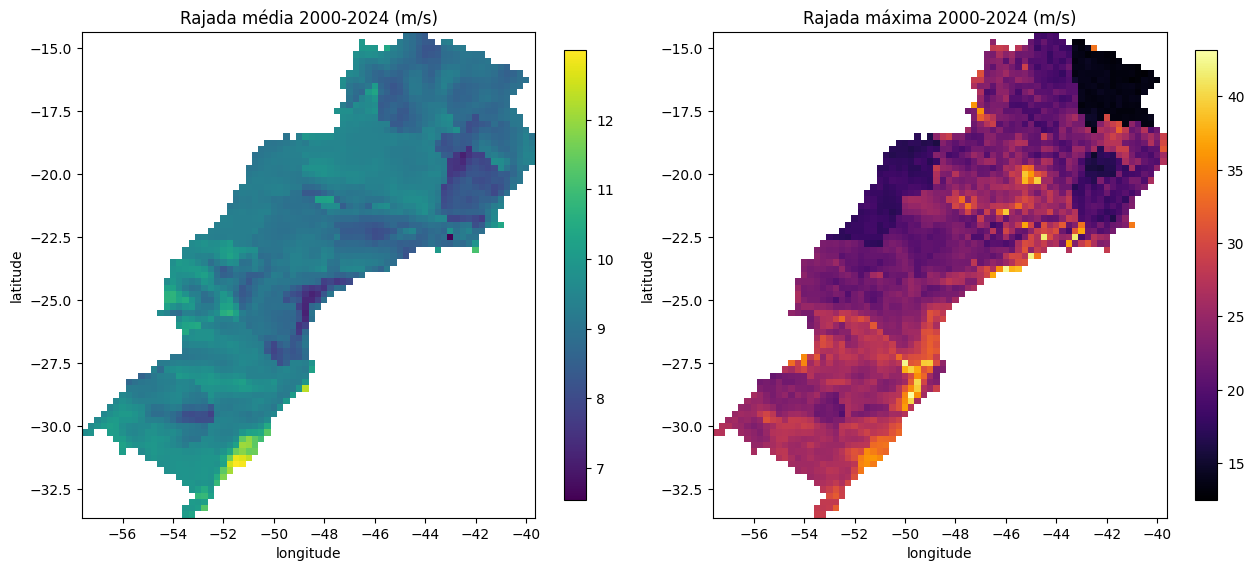

média: 9.18 m/s  |  máximo absoluto: 43.14 m/s


In [6]:
gust_mean = gust.mean("time").values
gust_max = gust.max("time").values

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plot_map(gust_mean, "Rajada média 2000-2024 (m/s)", cmap="viridis", ax=axes[0])
plot_map(gust_max, "Rajada máxima 2000-2024 (m/s)", cmap="inferno", ax=axes[1])
plt.tight_layout()
plt.show()

print(f"média: {gust_mean.mean():.2f} m/s  |  máximo absoluto: {gust_max.max():.2f} m/s")


### 2.2 Climatologia sazonal (DJF/MAM/JJA/SON)

Hemisfério sul: DJF = verão, JJA = inverno. São os mesmos trimestres que
definem qual modelo vence em cada cluster (seção 5), então diferenças
sazonais aqui refletem tanto o clima quanto a troca de modelo.


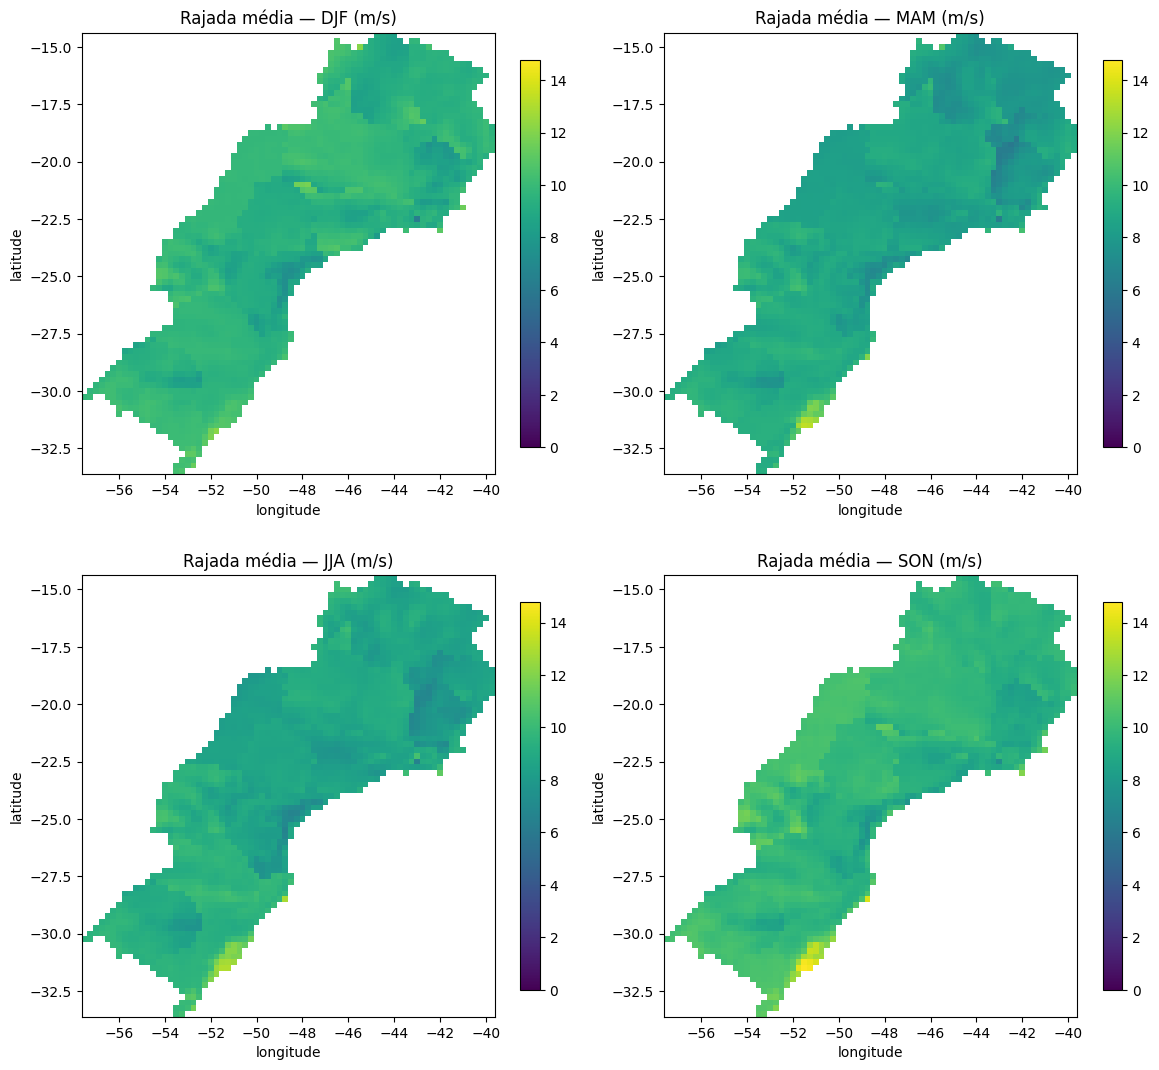

season
DJF    9.51
MAM    8.63
JJA    8.86
SON    9.75


In [7]:
seasonal = gust.groupby("time.season").mean("time")
ordem = ["DJF", "MAM", "JJA", "SON"]
vmax = float(seasonal.max())

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for s, ax in zip(ordem, axes.ravel()):
    plot_map(seasonal.sel(season=s).values, f"Rajada média — {s} (m/s)",
             cmap="viridis", ax=ax, vmin=0, vmax=vmax)
plt.tight_layout()
plt.show()

print(seasonal.mean("cell").to_series().reindex(ordem).round(2).to_string())


### 2.3 Efeito da correção (previsto − ERA5 bruto)

O produto anterior trazia uma variável `bias` explícita. Aqui não há: a predição
é direta, não uma soma de resíduo. O análogo é comparar contra o ERA5 bruto
(`ws_max`), que é a entrada que o modelo recebeu.


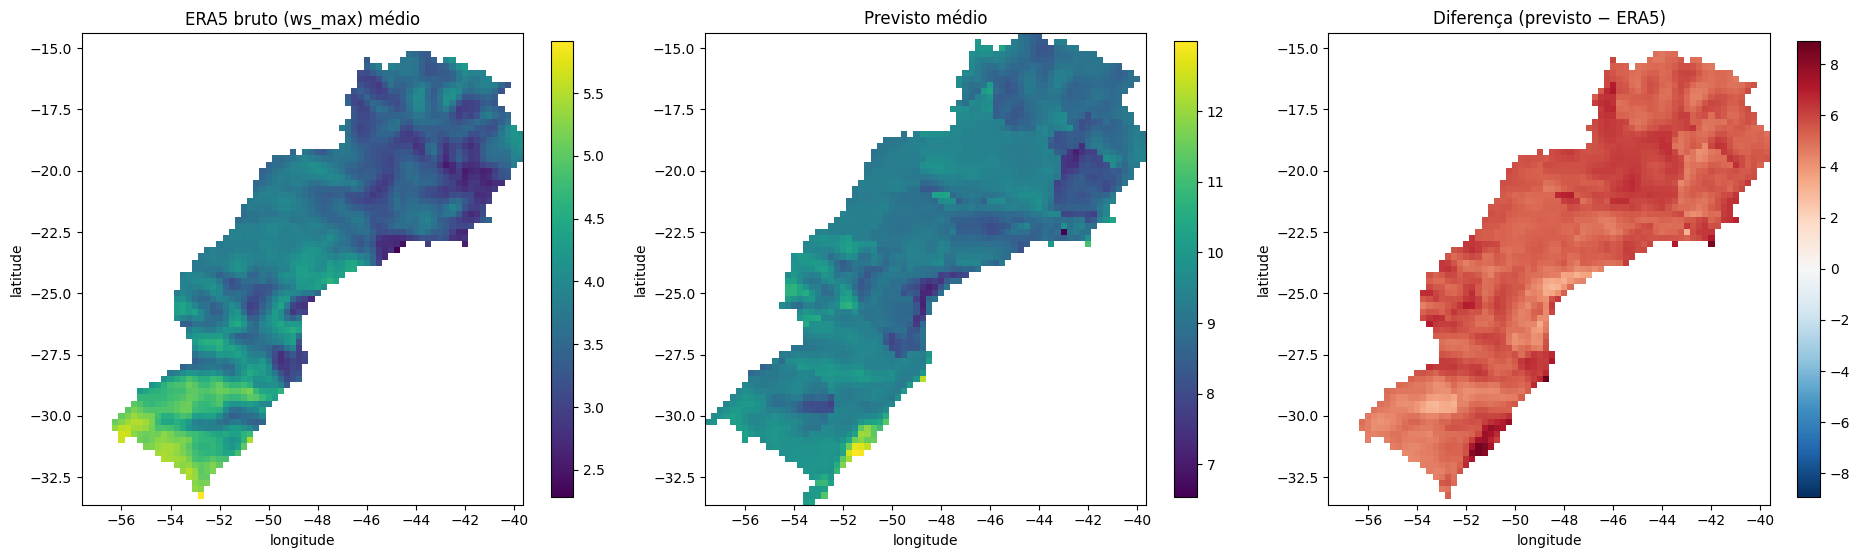

ERA5 bruto médio : nan m/s
Previsto médio   : 9.18 m/s
Aumento médio    : +nan m/s  (+nan%)

A correção é sistematicamente positiva: o ERA5 subestima rajada porque é
média de célula de 0.25°, enquanto a observação INMET é pontual.


In [8]:
era5 = xr.open_dataset(ERA5_FILE, chunks={"time": 365})["ws_max"]
era5 = era5.sel(time=slice(str(t.min().date()), str(t.max().date())))

# Média temporal do ERA5 na mesma máscara de células
era5_mean_grid = era5.mean("time").compute()
era5_mean = era5_mean_grid.values[LAT_IDX, LON_IDX]

delta = gust_mean - era5_mean
vmax = float(np.nanmax(np.abs(delta)))

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
plot_map(era5_mean, "ERA5 bruto (ws_max) médio", cmap="viridis", ax=axes[0])
plot_map(gust_mean, "Previsto médio", cmap="viridis", ax=axes[1])
plot_map(delta, "Diferença (previsto − ERA5)", cmap="RdBu_r",
         ax=axes[2], vmin=-vmax, vmax=vmax)
plt.tight_layout()
plt.show()

print(f"ERA5 bruto médio : {era5_mean.mean():.2f} m/s")
print(f"Previsto médio   : {gust_mean.mean():.2f} m/s")
print(f"Aumento médio    : {delta.mean():+.2f} m/s  ({100 * delta.mean() / era5_mean.mean():+.1f}%)")
print()
print("A correção é sistematicamente positiva: o ERA5 subestima rajada porque é")
print("média de célula de 0.25°, enquanto a observação INMET é pontual.")


### 2.4 Clusters — o domínio e quem governa cada região

Novidade do formato: cada célula carrega seu `cluster_id`. São os 14 clusters
que definem o domínio (a união deles é exatamente a máscara do dado) e que
determinam qual modelo prevê onde.


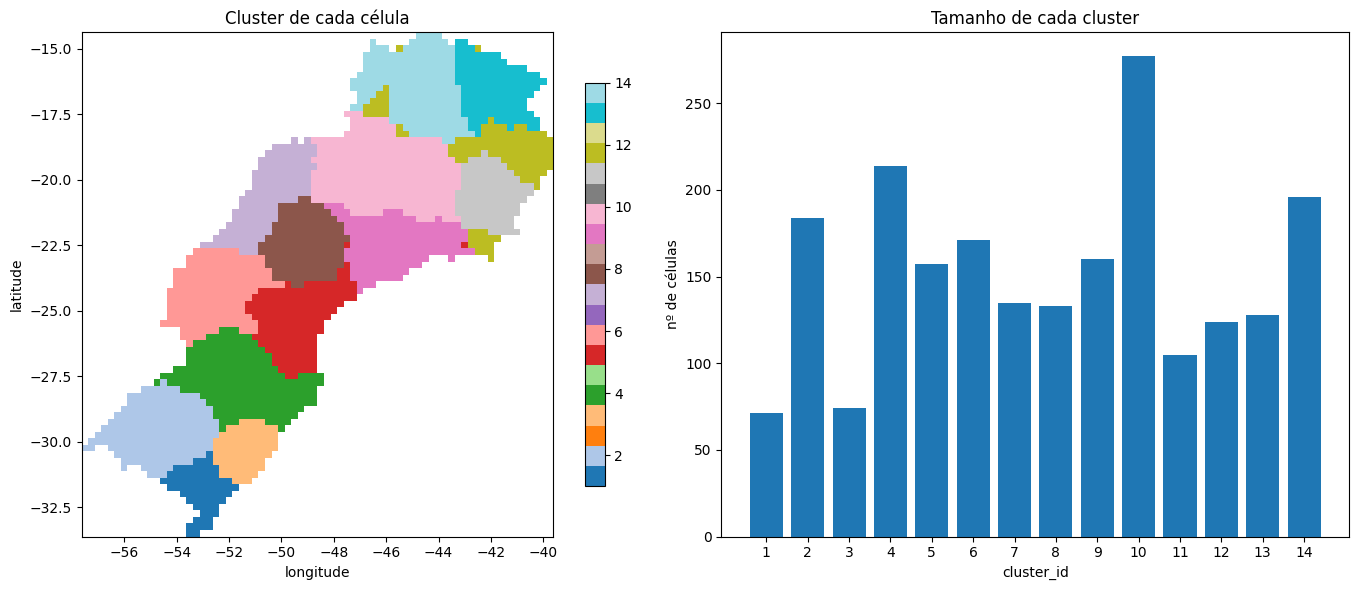

         n_celulas  rajada_media  rajada_maxima
cluster                                        
1               71         10.04      33.939999
2              184          9.37      30.750000
3               74         10.17      35.970001
4              214          9.51      43.139999
5              157          8.58      32.290001
6              171          9.56      32.660000
7              135          9.26      19.980000
8              133          9.09      25.920000
9              160          8.88      42.639999
10             277          9.37      39.740002
11             105          8.28      34.139999
12             124          8.99      33.660000
13             128          8.88      14.990000
14             196          8.92      36.060001


In [9]:
cid = ds.cluster_id.values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_map(cid, "Cluster de cada célula", cmap="tab20", ax=axes[0])

tam = pd.Series(cid).value_counts().sort_index()
axes[1].bar(tam.index, tam.values, color="tab:blue")
axes[1].set_xlabel("cluster_id"); axes[1].set_ylabel("nº de células")
axes[1].set_title("Tamanho de cada cluster")
axes[1].set_xticks(tam.index)
plt.tight_layout()
plt.show()

por_cluster = (pd.DataFrame({"cluster": cid, "media": gust_mean, "maximo": gust_max})
               .groupby("cluster").agg(n_celulas=("media", "size"),
                                       rajada_media=("media", "mean"),
                                       rajada_maxima=("maximo", "max")))
print(por_cluster.round(2).to_string())


## 3. Análise temporal <a id="3"></a>

### 3.1 Série diária média e máxima da bacia


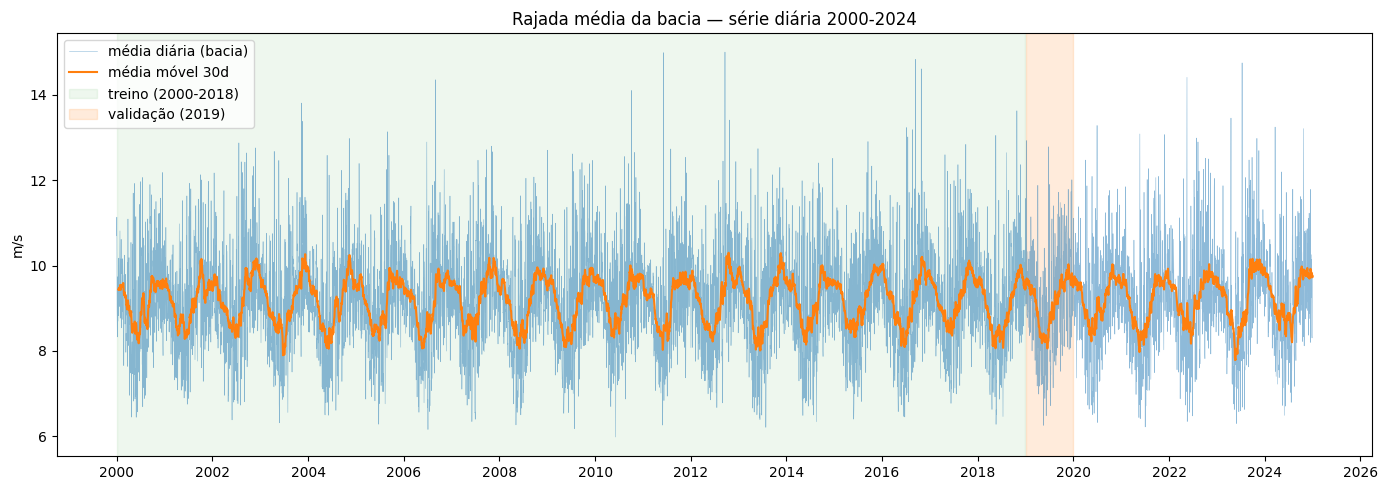

In [10]:
serie = pd.DataFrame({
    "mean": gust.mean("cell").to_series(),
    "max": gust.max("cell").to_series(),
})

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie.index, serie["mean"], lw=0.4, alpha=0.5, label="média diária (bacia)")
ax.plot(serie.index, serie["mean"].rolling(30, min_periods=15).mean(), lw=1.5,
        label="média móvel 30d")
ax.axvspan(pd.Timestamp(TRAIN_SLICE[0]), pd.Timestamp(TRAIN_SLICE[1]),
           color="tab:green", alpha=0.08, label="treino (2000-2018)")
ax.axvspan(pd.Timestamp(VAL_SLICE[0]), pd.Timestamp(VAL_SLICE[1]),
           color="tab:orange", alpha=0.15, label="validação (2019)")
ax.set_title("Rajada média da bacia — série diária 2000-2024")
ax.set_ylabel("m/s"); ax.legend(loc="upper left")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()


### 3.2 Tendência anual

**Diferença importante em relação ao produto anterior**: lá, 2000-2007 tinha
cobertura parcial (faltavam até 42% das células), o que distorcia médias anuais.
Aqui a cobertura é idêntica em todos os anos, então a comparação entre anos é
legítima. O que ainda difere entre os anos é a densidade de estações que
treinou o modelo (2 estações em 2000, 170+ a partir de 2008).


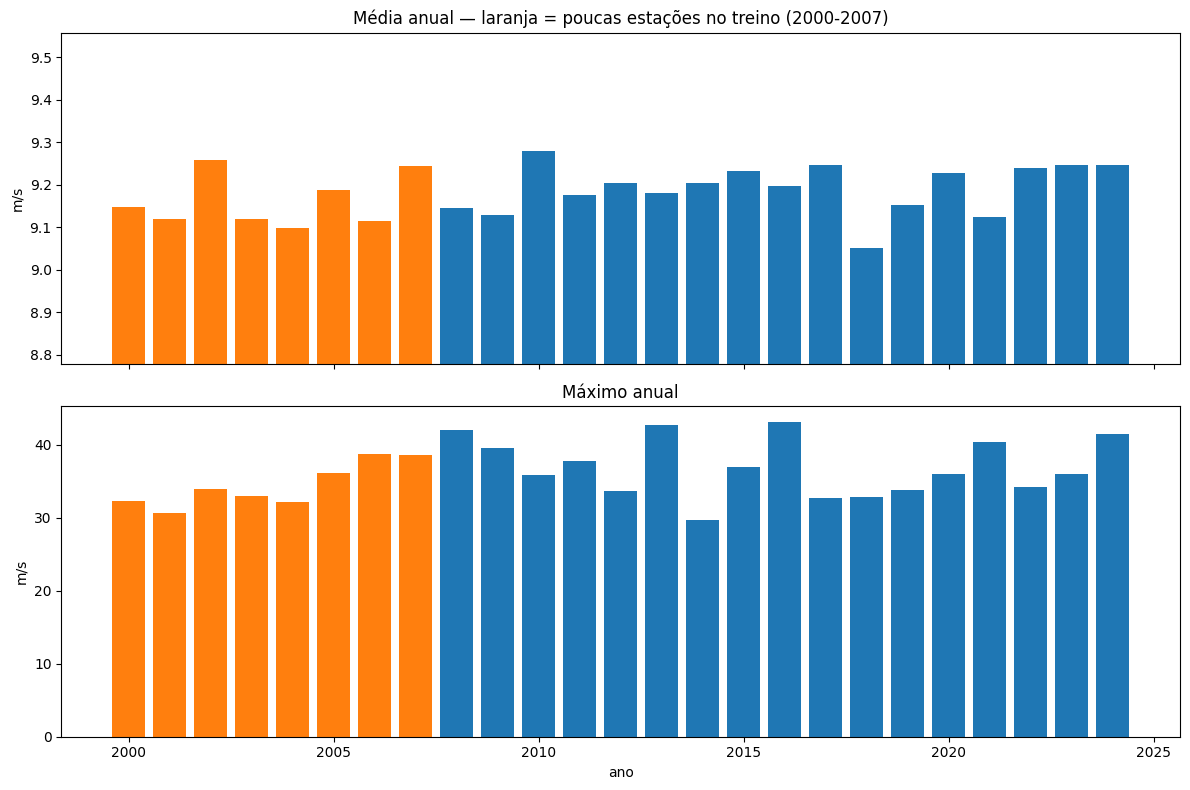

      media     maximo
time                  
2000   9.15  32.279999
2001   9.12  30.690001
2002   9.26  33.950001
2003   9.12  32.980000
2004   9.10  32.150002
2005   9.19  36.060001
2006   9.11  38.759998
2007   9.24  38.549999
2008   9.15  41.980000
2009   9.13  39.590000
2010   9.28  35.889999
2011   9.18  37.750000
2012   9.20  33.639999
2013   9.18  42.639999
2014   9.20  29.740000
2015   9.23  36.939999
2016   9.20  43.139999
2017   9.25  32.660000
2018   9.05  32.830002
2019   9.15  33.830002
2020   9.23  35.930000
2021   9.12  40.299999
2022   9.24  34.189999
2023   9.25  35.970001
2024   9.25  41.389999


In [11]:
anual = serie.groupby(serie.index.year).agg(media=("mean", "mean"), maximo=("max", "max"))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
cores = ["tab:orange" if a < 2008 else "tab:blue" for a in anual.index]
axes[0].bar(anual.index, anual["media"], color=cores)
axes[0].set_ylabel("m/s")
axes[0].set_title("Média anual — laranja = poucas estações no treino (2000-2007)")
axes[0].set_ylim(anual["media"].min() * 0.97, anual["media"].max() * 1.03)
axes[1].bar(anual.index, anual["maximo"], color=cores)
axes[1].set_ylabel("m/s"); axes[1].set_xlabel("ano")
axes[1].set_title("Máximo anual")
plt.tight_layout()
plt.show()

print(anual.round(2).to_string())


### 3.3 Ciclo sazonal (todos os anos empilhados)


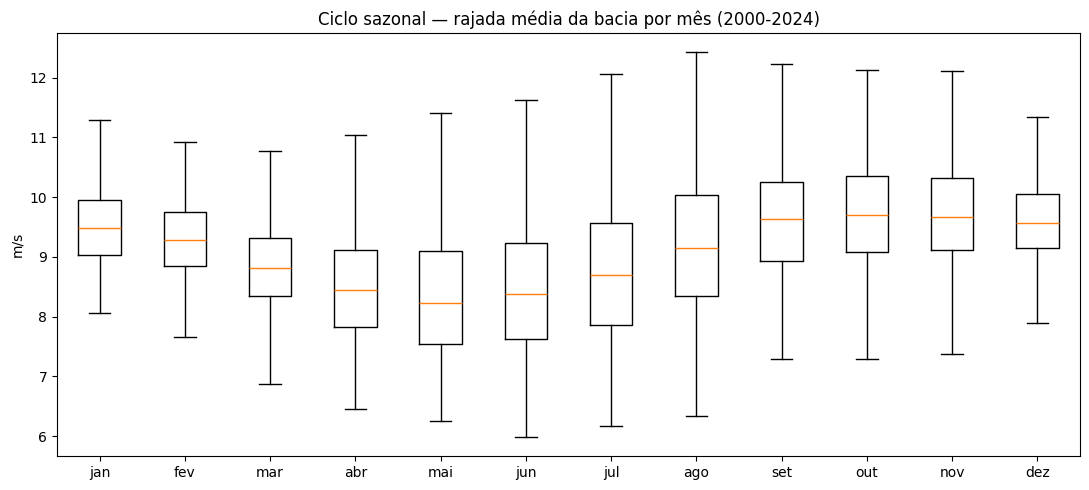

In [12]:
por_mes = [serie.loc[serie.index.month == m, "mean"].values for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(por_mes, tick_labels=["jan", "fev", "mar", "abr", "mai", "jun",
                                 "jul", "ago", "set", "out", "nov", "dez"],
           showfliers=False)
ax.set_title("Ciclo sazonal — rajada média da bacia por mês (2000-2024)")
ax.set_ylabel("m/s")
plt.tight_layout()
plt.show()


### 3.4 Dias mais extremos

Atenção ao interpretar: a cauda deste produto é comprimida em relação ao
produto por IDW (ver seção 5.3). Estes são os dias mais extremos *segundo este
modelo*, e os valores tendem a ser menores que os do produto anterior.


In [13]:
top = serie["max"].nlargest(20)
campo = gust.sel(time=top.index).values          # (20, cell)
idx = campo.argmax(axis=1)

tabela = pd.DataFrame({
    "data": [d.date() for d in top.index],
    "rajada_max_m_s": campo.max(axis=1),
    "lat": ds.latitude.values[idx],
    "lon": ds.longitude.values[idx],
    "cluster": ds.cluster_id.values[idx],
}).sort_values("rajada_max_m_s", ascending=False).reset_index(drop=True)
tabela.round(2)


,data,rajada_max_m_s,lat,lon,cluster
0,2016-07-06,43.139999,-28.75,-49.75,4
1,2013-06-29,42.639999,-23.75,-46.00,9
2,2016-07-07,42.369999,-27.50,-50.00,4
3,2008-08-07,41.980000,-23.25,-45.00,9
4,2008-11-03,41.520000,-22.50,-44.50,9
5,2024-07-14,41.389999,-22.50,-43.25,9
6,2021-05-23,40.299999,-28.25,-49.50,4
7,2008-08-30,39.740002,-20.25,-44.75,10
8,2009-08-03,39.590000,-27.50,-49.00,4
9,2016-12-25,39.410000,-21.50,-46.00,9


### 3.5 Distribuição por split (treino / validação / teste)

O produto anterior comparava dentro vs. fora do período de treino usando a flag
`in_sample`. Com o treino cobrindo 2000-2018, essa flag deixou de discriminar
(seria `True` para 19 dos 25 anos), então a comparação útil agora é entre os
três splits — sobretudo validação (2019) e teste (2020-2024), que são a
evidência real de generalização.


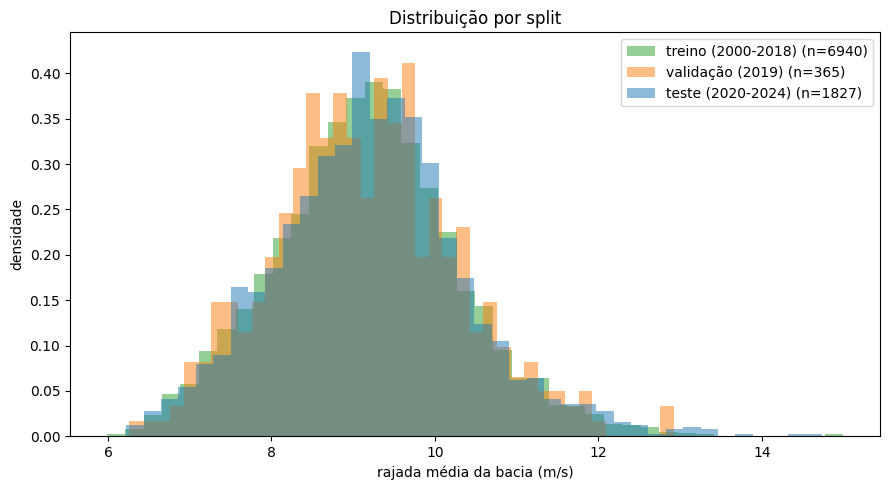

                     count  mean   std   min   25%   50%   75%    max
split                                                                
teste (2020-2024)   1827.0  9.22  1.17  6.22  8.44  9.20  9.90  14.74
treino (2000-2018)  6940.0  9.18  1.13  5.99  8.44  9.16  9.86  14.99
validação (2019)     365.0  9.15  1.13  6.26  8.40  9.11  9.86  12.93


In [14]:
def split_de(data):
    if data <= pd.Timestamp(TRAIN_SLICE[1]):
        return "treino (2000-2018)"
    if data <= pd.Timestamp(VAL_SLICE[1]):
        return "validação (2019)"
    return "teste (2020-2024)"


serie["split"] = [split_de(d) for d in serie.index]

fig, ax = plt.subplots(figsize=(9, 5))
for nome, cor in [("treino (2000-2018)", "tab:green"),
                  ("validação (2019)", "tab:orange"),
                  ("teste (2020-2024)", "tab:blue")]:
    sub = serie.loc[serie["split"] == nome, "mean"]
    ax.hist(sub, bins=40, alpha=0.5, density=True, color=cor,
            label=f"{nome} (n={len(sub)})")
ax.set_xlabel("rajada média da bacia (m/s)"); ax.set_ylabel("densidade")
ax.set_title("Distribuição por split")
ax.legend()
plt.tight_layout()
plt.show()

print(serie.groupby("split")["mean"].describe().round(2).to_string())


## 4. Séries em pontos específicos <a id="4"></a>

Escolhe 3 células programaticamente (mais ventosa, mais variável, e a de maior
extremo) em vez de coordenadas hardcoded. Ajuste `alvo_lat`/`alvo_lon` abaixo
para inspecionar um ponto seu.


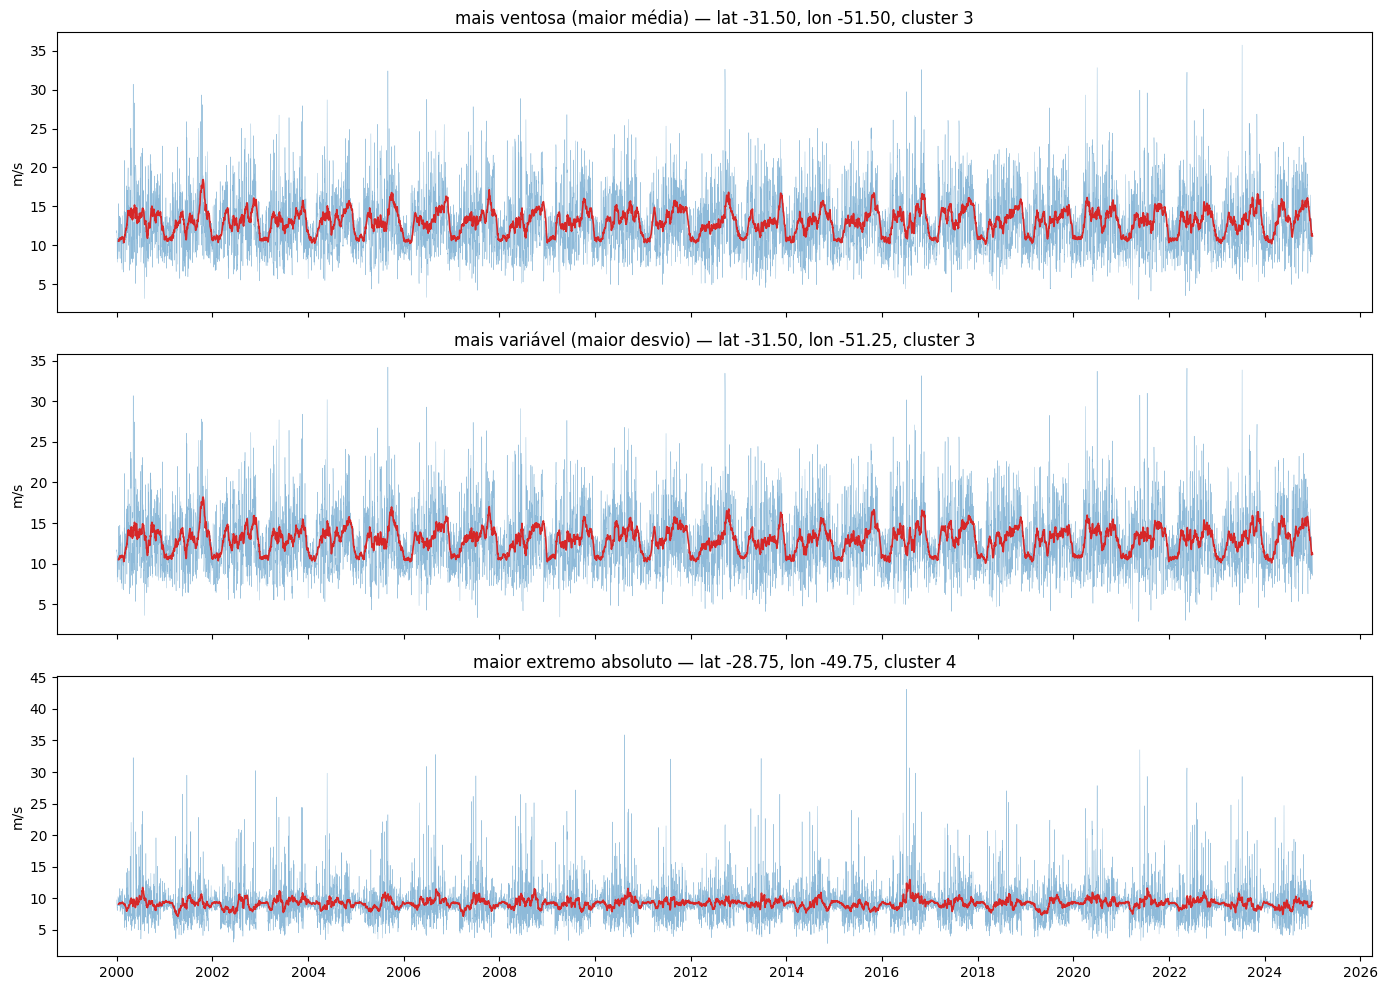

In [15]:
gust_std = gust.std("time").values

pontos = {
    "mais ventosa (maior média)": int(np.argmax(gust_mean)),
    "mais variável (maior desvio)": int(np.argmax(gust_std)),
    "maior extremo absoluto": int(np.argmax(gust_max)),
}

fig, axes = plt.subplots(len(pontos), 1, figsize=(14, 10), sharex=True)
for ax, (rotulo, ci) in zip(axes, pontos.items()):
    s = gust.isel(cell=ci).to_series()
    ax.plot(s.index, s.values, lw=0.3, alpha=0.5)
    ax.plot(s.index, s.rolling(30, min_periods=15).mean(), lw=1.2, color="tab:red")
    ax.set_title(f"{rotulo} — lat {ds.latitude.values[ci]:.2f}, "
                 f"lon {ds.longitude.values[ci]:.2f}, cluster {ds.cluster_id.values[ci]}")
    ax.set_ylabel("m/s")
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()


## 5. Modelos e qualidade <a id="5"></a>

### 5.1 Qual modelo governa cada cluster × trimestre


In [16]:
WINNERS = Path("../artifacts/corrected_grid/v1.01/winners.csv")
if not WINNERS.exists():
    WINNERS = Path("../winners_train2000.csv")   # fallback

if WINNERS.exists():
    w = pd.read_csv(WINNERS)
    w = w[w["season"] != "ALL"]
    print(f"Combos cluster × trimestre: {len(w)}")
    print()
    print("Distribuição por pipeline:")
    print(w["pipeline"].value_counts().to_string())
    print()
    pivot = w.pivot(index="cluster_id", columns="season", values="pipeline")
    print(pivot.reindex(columns=["DJF", "MAM", "JJA", "SON"]).to_string())
else:
    print(f"[AVISO] tabela de vencedores não encontrada em {WINNERS}.")
    print("Ela é o registro de qual modelo gerou cada célula — vale versionar")
    print("junto do .nc (ver attrs['winners_csv'] do dataset).")


Combos cluster × trimestre: 56

Distribuição por pipeline:
pipeline
lstm    29
mlp     17
lazy    10

season       DJF   MAM   JJA   SON
cluster_id                        
1           lstm  lstm  lstm  lstm
2           lstm  lstm  lstm  lstm
3           lazy  lstm  lstm  lstm
4           lazy  lstm  lstm  lstm
5           lstm  lstm  lstm  lstm
6           lstm  lstm  lstm  lstm
7           lazy  lazy  lazy  lazy
8           lstm  lstm  lstm  lstm
9            mlp   mlp   mlp   mlp
10           mlp   mlp   mlp   mlp
11          lstm   mlp   mlp  lstm
12           mlp   mlp   mlp   mlp
13          lazy  lazy  lazy  lazy
14           mlp   mlp   mlp  lstm


### 5.2 Distribuição espacial do pipeline vencedor

Mapeia, por trimestre, qual pipeline governa cada célula. Descontinuidades nas
fronteiras entre clusters são esperadas — modelos diferentes, treinados
separadamente, se encontram ali.


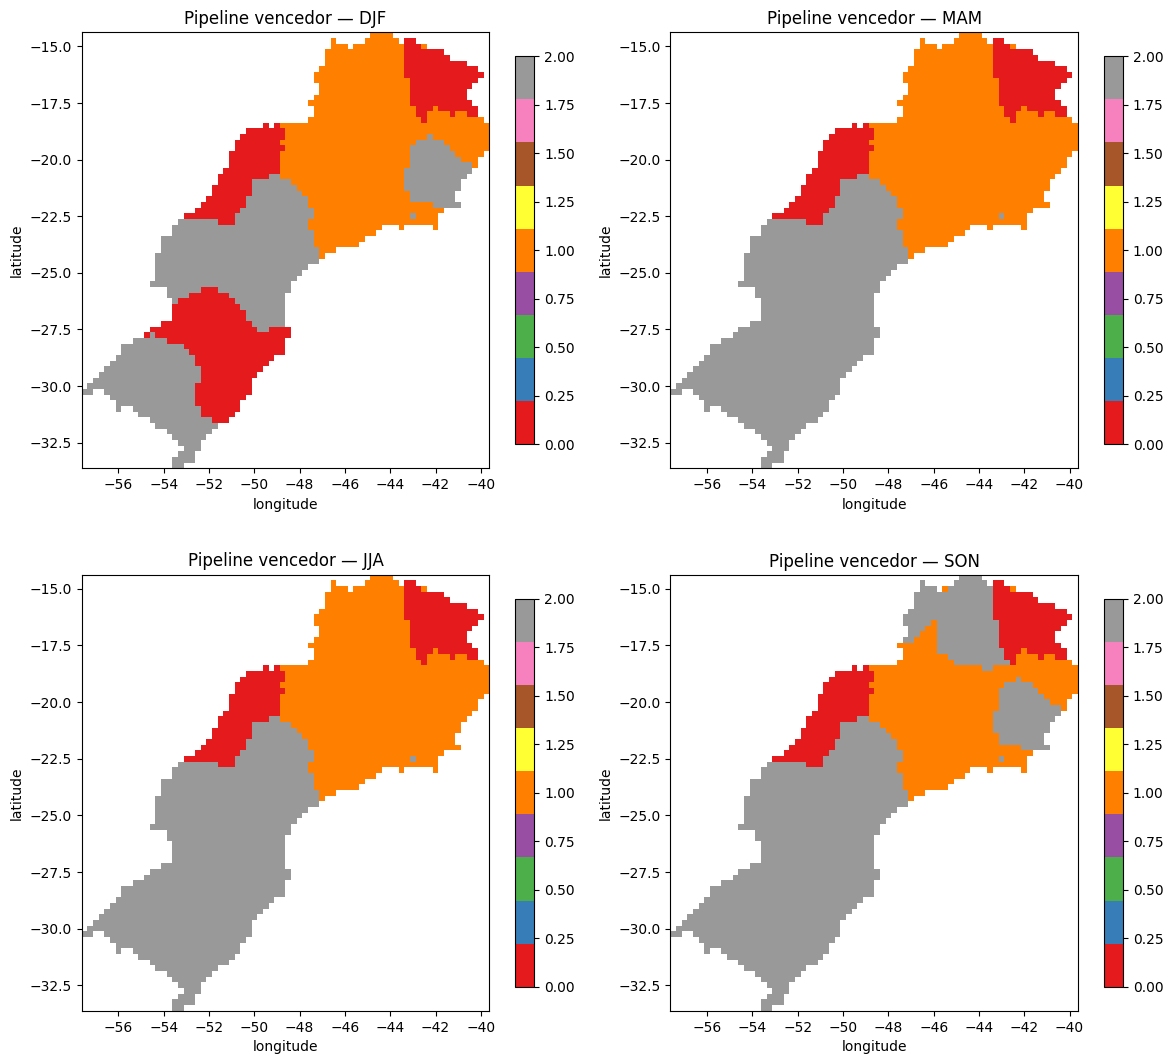

Código de cor: 0 = lazy, 1 = mlp, 2 = lstm


In [17]:
if WINNERS.exists():
    ordem_pipe = {"lazy": 0, "mlp": 1, "lstm": 2}
    fig, axes = plt.subplots(2, 2, figsize=(12, 11))
    for s, ax in zip(["DJF", "MAM", "JJA", "SON"], axes.ravel()):
        mapa = w[w["season"] == s].set_index("cluster_id")["pipeline"]
        vals = np.array([ordem_pipe.get(mapa.get(c), np.nan) for c in cid], dtype=float)
        plot_map(vals, f"Pipeline vencedor — {s}", cmap="Set1", ax=ax, vmin=0, vmax=2)
    plt.tight_layout()
    plt.show()
    print("Código de cor: 0 = lazy, 1 = mlp, 2 = lstm")


### 5.3 Comparação com o produto anterior (IDW de resíduo)

Compara este produto com `v102_2000_2024` nas células e dias em que ambos têm
valor. É aqui que aparece a limitação principal: a cauda comprimida.


Comparando contra v1 (anos 2020-2024) | ano escolhido: 2022
Ano 2022 — 658,825 pares célula×dia com valor nos dois produtos
percentil  IDW (anterior)  predição direta  diferença
      p50            8.65         8.930000       0.28
      p90           11.07        12.250000       1.18
      p95           12.00        13.650000       1.65
      p99           14.51        17.040001       2.53
    p99.9           18.02        22.260000       4.24
   máximo           26.15        34.189999       8.04


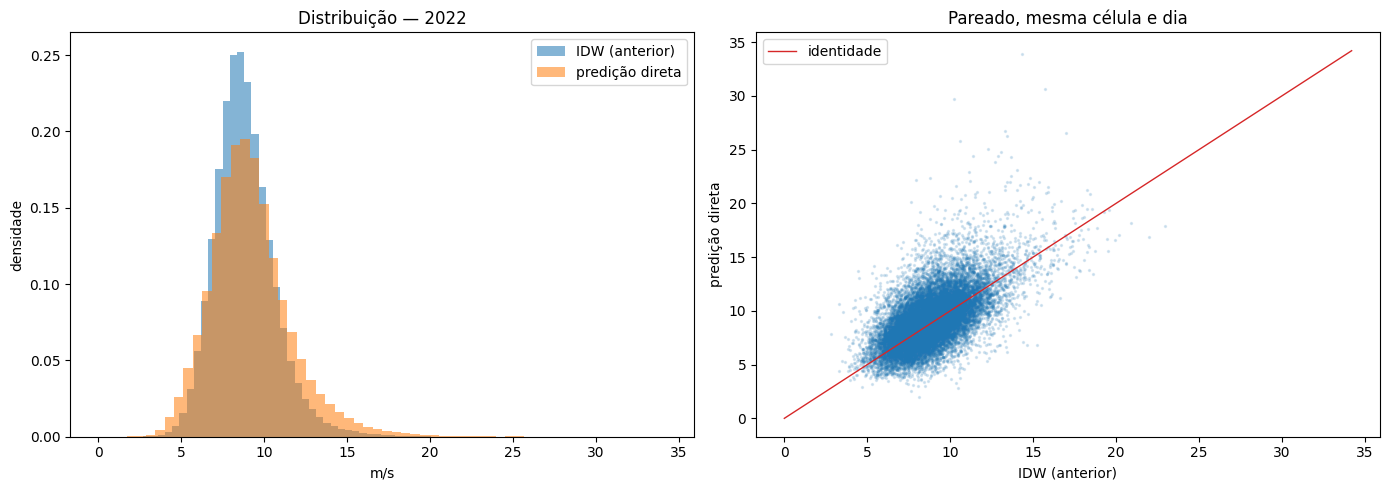

In [18]:
# Os diretórios do produto IDW são montados com SYMLINKS (ver
# scripts/merge_corrected_grid_periods.py). Se a origem for movida, os links
# ficam pendurados: `glob` ainda os lista, mas abrir falha. Então procura o
# primeiro diretório cujos arquivos RESOLVEM de fato.
CANDIDATOS = [IDW_DIR,
              Path("../artifacts/corrected_grid/v1.1_2000_2019_fix"),
              Path("../artifacts/corrected_grid/v1.1"),
              Path("../artifacts/corrected_grid/v1")]

idw_files, IDW_USADO = [], None
for cand in CANDIDATOS:
    if not cand.exists():
        continue
    reais = [p for p in sorted(cand.glob("grid_corrected_*.nc")) if p.exists()]
    if reais:
        idw_files, IDW_USADO = reais, cand
        break

if IDW_USADO is None:
    print("[INFO] Nenhum produto IDW com arquivos validos. Inspecionados:")
    for cand in CANDIDATOS:
        if not cand.exists():
            print(f"  {cand.name}: nao existe")
        else:
            links = list(cand.glob("grid_corrected_*.nc"))
            print(f"  {cand.name}: {len(links)} entradas, "
                  f"{sum(p.exists() for p in links)} resolvem")
    print()
    print("Comparacao pulada — sem produto anterior em disco.")
else:
    anos_idw = sorted({int(p.stem.split("_")[-1]) for p in idw_files})
    comuns = [a for a in anos_idw if a in set(t.year)]
    ano = comuns[len(comuns) // 2]
    print(f"Comparando contra {IDW_USADO.name} "
          f"(anos {anos_idw[0]}-{anos_idw[-1]}) | ano escolhido: {ano}")
    f = [p for p in idw_files if p.stem.endswith(str(ano))]
    old = xr.open_dataset(f[0])["rajada_max_corrigida"]
    old_cells = old.values[:, LAT_IDX, LON_IDX]          # (time, cell)
    new_cells = gust.sel(time=slice(f"{ano}-01-01", f"{ano}-12-31")).values

    n = min(len(old_cells), len(new_cells))
    a, b = old_cells[:n].ravel(), new_cells[:n].ravel()
    ok = np.isfinite(a) & np.isfinite(b)

    qs = [50, 90, 95, 99, 99.9]
    comp = pd.DataFrame({
        "percentil": [f"p{q}" for q in qs] + ["máximo"],
        "IDW (anterior)": [np.percentile(a[ok], q) for q in qs] + [a[ok].max()],
        "predição direta": [np.percentile(b[ok], q) for q in qs] + [b[ok].max()],
    })
    comp["diferença"] = comp["predição direta"] - comp["IDW (anterior)"]
    print(f"Ano {ano} — {ok.sum():,} pares célula×dia com valor nos dois produtos")
    print(comp.round(2).to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(a[ok], bins=60, alpha=0.55, density=True, label="IDW (anterior)")
    axes[0].hist(b[ok], bins=60, alpha=0.55, density=True, label="predição direta")
    axes[0].set_xlabel("m/s"); axes[0].set_ylabel("densidade")
    axes[0].set_title(f"Distribuição — {ano}"); axes[0].legend()

    idx = np.random.default_rng(0).choice(np.where(ok)[0], size=min(20000, ok.sum()),
                                          replace=False)
    axes[1].scatter(a[idx], b[idx], s=2, alpha=0.15)
    lim = [0, max(a[ok].max(), b[ok].max())]
    axes[1].plot(lim, lim, color="tab:red", lw=1, label="identidade")
    axes[1].set_xlabel("IDW (anterior)"); axes[1].set_ylabel("predição direta")
    axes[1].set_title("Pareado, mesma célula e dia"); axes[1].legend()
    plt.tight_layout()
    plt.show()


## 6. Exploração interativa por data <a id="6"></a>

Escolha uma data e veja o campo previsto, o ERA5 bruto que o alimentou, e a
diferença entre os dois.


In [19]:
import ipywidgets as widgets
from IPython.display import clear_output, display

datas = pd.DatetimeIndex(ds.time.values)

seletor = widgets.DatePicker(description="Data:", value=datas.max().date())
botao = widgets.Button(description="Plotar dia", button_style="primary")
saida = widgets.Output()


def ao_clicar(_):
    with saida:
        clear_output(wait=True)
        alvo = pd.Timestamp(seletor.value)
        if alvo not in datas:
            prox = datas[np.argmin(np.abs(datas - alvo))]
            print(f"{alvo.date()} fora do range — usando {prox.date()}")
            alvo = prox

        prev = gust.sel(time=alvo).values
        bruto = era5.sel(time=alvo).compute().values[LAT_IDX, LON_IDX]
        dif = prev - bruto

        fig, axes = plt.subplots(1, 3, figsize=(19, 6))
        vmax = float(max(np.nanmax(prev), np.nanmax(bruto)))
        plot_map(bruto, f"ERA5 bruto — {alvo.date()}", cmap="viridis",
                 ax=axes[0], vmin=0, vmax=vmax)
        plot_map(prev, f"Previsto — {alvo.date()}", cmap="viridis",
                 ax=axes[1], vmin=0, vmax=vmax)
        d = float(np.nanmax(np.abs(dif)))
        plot_map(dif, "Diferença (previsto − ERA5)", cmap="RdBu_r",
                 ax=axes[2], vmin=-d, vmax=d)
        plt.tight_layout()
        plt.show()

        split = split_de(alvo)
        print(f"Split: {split}  |  previsto: média {prev.mean():.2f}, "
              f"máx {prev.max():.2f} m/s  |  ERA5: média {bruto.mean():.2f} m/s")


botao.on_click(ao_clicar)
display(widgets.HBox([seletor, botao]), saida)
ao_clicar(None)


Output()

## 7. Resumo <a id="7"></a>

- **Cobertura completa**: 2129 células × 9132 dias, **zero NaN**, sem o gap de 7
  dias de jan/2020 que existia no produto anterior. 2000-2007 tem a mesma
  cobertura de 2008-2024 — era exatamente o objetivo da mudança de método.
- **Resolução diária**: um valor por célula por dia, à meia-noite; o alvo do
  treino é `daily_wind_gust_max`.
- **Correção sistemática do ERA5**: o previsto é substancialmente maior que o
  ERA5 bruto (seção 2.3), como esperado — o ERA5 é média de célula de 0.25° e
  subestima rajada pontual.
- **Limitação principal — extremos** (seção 5.3): a cauda é comprimida em
  relação ao produto por IDW. Para climatologia e cobertura contínua este
  produto é melhor; para análise de evento severo, o produto por IDW continua
  mais sensível. Vale tratá-los como complementares, não como substitutos.
- **Evidência de generalização é estreita**: com treino em 2000-2018, sobram só
  2019 (validação) e 2020-2024 (teste) fora da amostra.

Próximos passos sugeridos: validar os dias extremos da seção 3.4 contra
registros conhecidos de vendaval na região; e versionar a tabela de vencedores
junto do `.nc` (hoje ela vive fora do diretório do produto).
